In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
movies = pd.read_csv("D:/Projects/movie_recommendation_system/data/movies.csv")
ratings = pd.read_csv("D:/Projects/movie_recommendation_system/data/ratings.csv")
tags = pd.read_csv("D:/Projects/movie_recommendation_system/data/tags.csv")
links = pd.read_csv("D:/Projects/movie_recommendation_system/data/links.csv")

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [7]:
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

print("Unique movies:", movies["movieId"].nunique())
print("Unique users:", ratings["userId"].nunique())

Movies shape: (9742, 3)
Ratings shape: (100836, 4)
Tags shape: (3683, 4)
Links shape: (9742, 3)
Unique movies: 9742
Unique users: 610


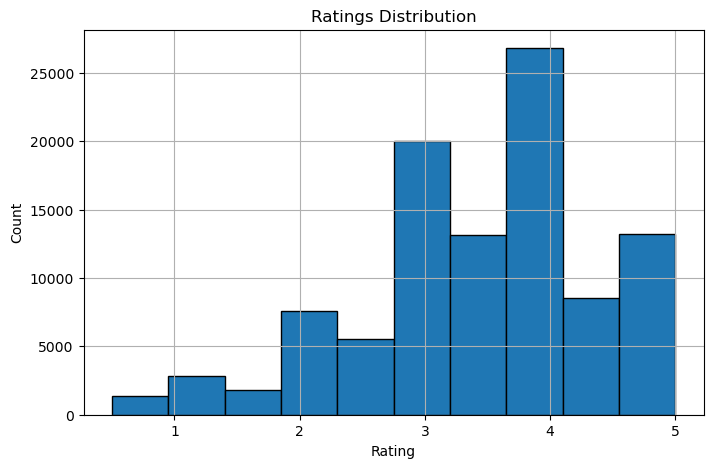

In [8]:
plt.figure(figsize=(8, 5))
ratings["rating"].hist(bins=10, edgecolor="black")
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [9]:
rating_counts = ratings.groupby("movieId").size().reset_index(name="num_ratings")
top_movies = rating_counts.merge(movies, on="movieId").sort_values("num_ratings", ascending=False).head(10)
top_movies[["title", "num_ratings"]]

,title,num_ratings
314,Forrest Gump (1994),329
277,"Shawshank Redemption, The (1994)",317
257,Pulp Fiction (1994),307
510,"Silence of the Lambs, The (1991)",279
1938,"Matrix, The (1999)",278
224,Star Wars: Episode IV - A New Hope (1977),251
418,Jurassic Park (1993),238
97,Braveheart (1995),237
507,Terminator 2: Judgment Day (1991),224
461,Schindler's List (1993),220


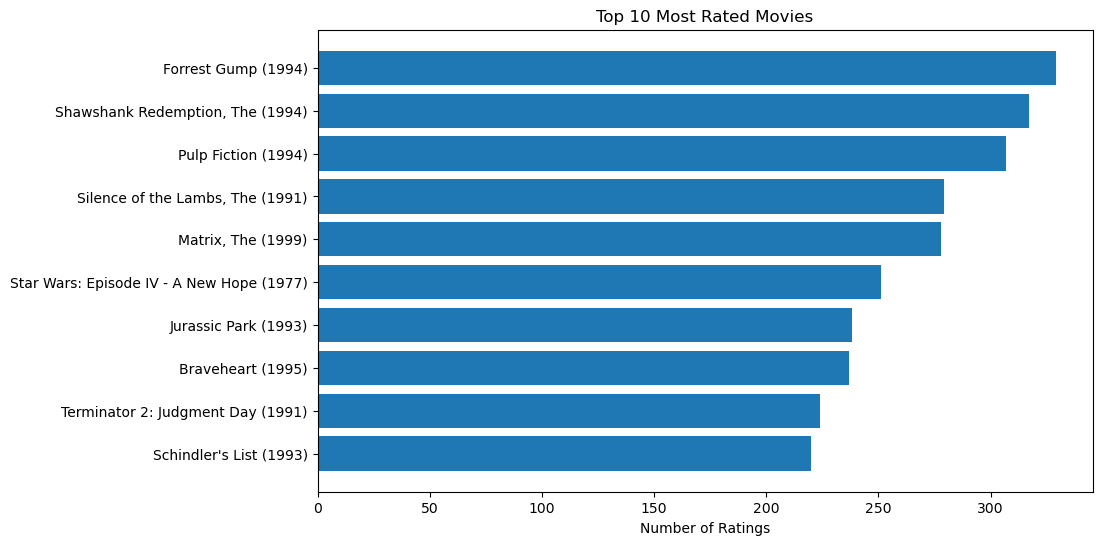

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(top_movies["title"], top_movies["num_ratings"])
plt.gca().invert_yaxis()
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.show()

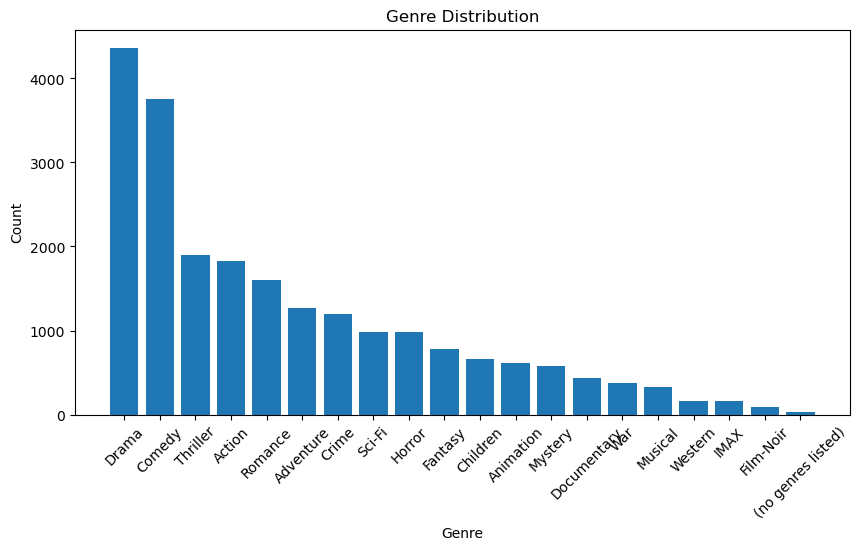

In [11]:
genre_series = movies["genres"].str.split("|").explode()
genre_counts = genre_series.value_counts()

plt.figure(figsize=(10, 5))
plt.bar(genre_counts.index, genre_counts.values)
plt.xticks(rotation=45)
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [12]:
tags["tag"] = tags["tag"].fillna("")

tags_grouped = tags.groupby("movieId")["tag"].apply(lambda x: " ".join(x)).reset_index()

final_df = pd.merge(movies, tags_grouped, on="movieId", how="left")
final_df["tag"] = final_df["tag"].fillna("")
final_df["genres"] = final_df["genres"].str.replace("|", " ", regex=False).str.lower()
final_df["tag"] = final_df["tag"].str.lower()
final_df["title"] = final_df["title"].str.strip()

final_df["metadata"] = final_df["genres"] + " " + final_df["tag"]

final_df.head()

,movieId,title,genres,tag,metadata
0,1,Toy Story (1995),adventure animation children comedy fantasy,pixar pixar fun,adventure animation children comedy fantasy pi...
1,2,Jumanji (1995),adventure children fantasy,fantasy magic board game robin williams game,adventure children fantasy fantasy magic board...
2,3,Grumpier Old Men (1995),comedy romance,moldy old,comedy romance moldy old
3,4,Waiting to Exhale (1995),comedy drama romance,,comedy drama romance
4,5,Father of the Bride Part II (1995),comedy,pregnancy remake,comedy pregnancy remake


In [13]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(final_df["metadata"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9742, 1677)


In [14]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (9742, 9742)


In [15]:
indices = pd.Series(final_df.index, index=final_df["title"].str.lower()).drop_duplicates()

In [16]:
def recommend_movies(movie_title, top_n=5):
    movie_title = movie_title.lower().strip()
    
    if movie_title not in indices:
        return "Movie not found"
    
    idx = indices[movie_title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    result = final_df.iloc[movie_indices][["title", "genres"]].copy()
    result["similarity_score"] = [round(score[1], 3) for score in sim_scores]
    
    return result

In [17]:
recommend_movies("Toy Story (1995)", top_n=5)

,title,genres,similarity_score
1757,"Bug's Life, A (1998)",adventure animation children comedy,0.862
2355,Toy Story 2 (1999),adventure animation children comedy fantasy,0.644
8695,Guardians of the Galaxy 2 (2017),action adventure sci-fi,0.368
1706,Antz (1998),adventure animation children comedy fantasy,0.358
2809,"Adventures of Rocky and Bullwinkle, The (2000)",adventure animation children comedy fantasy,0.358


In [18]:
recommend_movies("Jumanji (1995)", top_n=5)

,title,genres,similarity_score
9692,Tomb Raider (2018),action adventure fantasy,0.356
6254,Night at the Museum (2006),action comedy fantasy imax,0.354
53,"Indian in the Cupboard, The (1995)",adventure children fantasy,0.303
109,"NeverEnding Story III, The (1994)",adventure children fantasy,0.303
767,Escape to Witch Mountain (1975),adventure children fantasy,0.303
